#  Discretization (Binning) & Binarization - Complete Guide

##  Table of Contents
1. [ What is Discretization?](#theory)
2. [ Types of Binning Strategies](#types)
3. [ Practical Implementation](#implementation)
4. [ How to Choose Optimal Strategy](#optimization)
5. [ Key Takeaways & Best Practices](#summary)

---

## 1.  What is Discretization? <a id="theory"></a>

###  Definition
**Discretization** (also called **Binning**) is the process of converting **continuous numerical features** into **discrete categories (bins)**.

###  Example
**Before Discretization:**
```
Age: [18, 22, 25, 35, 42, 55, 60]
```

**After Discretization (3 bins):**
```
Age Bins: ["Young", "Adult", "Adult", "Adult", "Senior", "Senior", "Senior"]
Or:       [0, 0, 0, 1, 2, 2, 2]
```

###  Why Use Discretization?
1. **Reduces noise and outliers** 
2. **Simplifies complex relationships** 
3. **Makes features more interpretable** 
4. **Can improve model performance** 
5. **Handles non-linear relationships** 

###  When NOT to Use?
- When continuous values contain important patterns
- With very small datasets (risk of information loss)
- When linear relationships are sufficient

---

## 2.  Types of Binning Strategies <a id="types"></a>

###  A) Equal-Width Binning (Uniform)
**How it works:** Divides the range into intervals of **equal width**.

**Formula:** `bin_width = (max - min) / number_of_bins`

**Example:**
```
Data: [10, 20, 30, 40, 50, 90, 100]
Range: 10 to 100 (width = 90)
3 bins: [10-40), [40-70), [70-100]
Result: [0, 0, 0, 0, 1, 2, 2]
```

** Use When:**
- Data is fairly uniform/symmetric
- You want interpretable ranges
- Few outliers present

---

###  B) Equal-Frequency Binning (Quantile)
**How it works:** Each bin contains **approximately equal number** of data points.

**Example:**
```
Data: [10, 20, 30, 40, 50, 90, 100]  (7 points)
3 bins: ~2-3 points each
Bin 1: [10, 20]     → values 10, 20
Bin 2: [30, 40]     → values 30, 40  
Bin 3: [50, 90, 100] → values 50, 90, 100
Result: [0, 0, 1, 1, 2, 2, 2]
```

**Use When:**
- Data is highly skewed
- Many outliers present
- You want balanced sample sizes

---

###  C) K-Means Binning
**How it works:** Uses clustering to group similar values together.

**Steps:**
1. Choose number of bins (k)
2. Initialize k centroids randomly
3. Assign each point to nearest centroid
4. Update centroids to mean of assigned points
5. Repeat until convergence

**Example:**
```
Data: [1, 2, 3, 10, 11, 12, 50]
3 clusters might become:
Cluster 0: [1, 2, 3]     (centroid ≈ 2)
Cluster 1: [10, 11, 12]  (centroid ≈ 11)
Cluster 2: [50]          (centroid = 50)
Result: [0, 0, 0, 1, 1, 1, 2]
```

**Use When:**
- Data has natural clusters
- Complex/multi-modal distributions
- Want data-driven bins

---

## 3.  Practical Implementation <a id="implementation"></a>

Let's implement binning on the Titanic dataset step by step.

In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.compose import ColumnTransformer
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print(" All libraries imported successfully!")

 All libraries imported successfully!


###  Step 1: Load and Explore Data

In [3]:

df = pd.read_csv(r"C:\Users\Acer\OneDrive\Desktop\Machine Learning\CSV\tested.csv", 
                 usecols=["Age", "Fare", "Survived"])

print(f" Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\n Missing values before cleanup:")
print(df.isnull().sum())

df.dropna(inplace=True)
print(f"\n After removing missing values: {df.shape[0]} rows")

print("\n Data Overview:")
df.describe()

 Dataset loaded: 418 rows, 3 columns

 Missing values before cleanup:
Survived     0
Age         86
Fare         1
dtype: int64

 After removing missing values: 331 rows

 Data Overview:


,Survived,Age,Fare
count,331.000000,331.000000,331.000000
mean,0.383686,30.181269,40.982087
std,0.487019,14.104573,61.228558
min,0.000000,0.170000,0.000000
25%,0.000000,21.000000,8.050000
50%,0.000000,27.000000,16.000000
75%,1.000000,39.000000,40.633350
max,1.000000,76.000000,512.329200


###  Step 2: Prepare Data for Modeling

In [4]:
# Split features and target
X = df[['Age', 'Fare']]  # Features
y = df['Survived']       # Target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f" Training set: {X_train.shape[0]} samples")
print(f" Test set: {X_test.shape[0]} samples")
print(f"\n Target distribution:")
print(f"Training - Survived: {y_train.sum()}/{len(y_train)} ({y_train.mean():.1%})")
print(f"Test - Survived: {y_test.sum()}/{len(y_test)} ({y_test.mean():.1%})")

 Training set: 264 samples
 Test set: 67 samples

 Target distribution:
Training - Survived: 101/264 (38.3%)
Test - Survived: 26/67 (38.8%)


In [5]:
# Let's demonstrate the effect of stratification
print(" STRATIFICATION COMPARISON")
print("="*50)

# First, show original distribution
print(f" Original Dataset Distribution:")
print(f"   Total samples: {len(y)}")
print(f"   Survived (1): {y.sum()} ({y.mean():.1%})")
print(f"   Died (0): {len(y) - y.sum()} ({(1-y.mean()):.1%})")

print(f"\n WITH stratify=y (current approach):")
print(f"   Training - Survived: {y_train.sum()}/{len(y_train)} ({y_train.mean():.1%})")
print(f"   Test - Survived: {y_test.sum()}/{len(y_test)} ({y_test.mean():.1%})")
print(f"    Proportions are maintained!")

# Now let's see what happens WITHOUT stratification
X_train_no_strat, X_test_no_strat, y_train_no_strat, y_test_no_strat = train_test_split(
    X, y, test_size=0.2, random_state=42  # No stratify parameter
)

print(f"\n WITHOUT stratify (random split):")
print(f"   Training - Survived: {y_train_no_strat.sum()}/{len(y_train_no_strat)} ({y_train_no_strat.mean():.1%})")
print(f"   Test - Survived: {y_test_no_strat.sum()}/{len(y_test_no_strat)} ({y_test_no_strat.mean():.1%})")

# Check if proportions are different
diff_train = abs(y_train_no_strat.mean() - y.mean()) * 100
diff_test = abs(y_test_no_strat.mean() - y.mean()) * 100

if diff_train > 2 or diff_test > 2:
    print(f"     Proportions differ by {max(diff_train, diff_test):.1f}% from original!")
else:
    print(f"    Proportions are similar (difference < 2%)")
    
print(f"\n💡 Key Point: stratify=y ensures both sets represent the original data fairly!")

 STRATIFICATION COMPARISON
 Original Dataset Distribution:
   Total samples: 331
   Survived (1): 127 (38.4%)
   Died (0): 204 (61.6%)

 WITH stratify=y (current approach):
   Training - Survived: 101/264 (38.3%)
   Test - Survived: 26/67 (38.8%)
    Proportions are maintained!

 WITHOUT stratify (random split):
   Training - Survived: 105/264 (39.8%)
   Test - Survived: 22/67 (32.8%)
     Proportions differ by 5.5% from original!

💡 Key Point: stratify=y ensures both sets represent the original data fairly!


####  Understanding `stratify=y`

**What it does:** Ensures both training and test sets have the **same class distribution** as the original dataset.

**Why it's important:**
- **Prevents biased splits** where one set has mostly one class
- **Makes evaluation fair** - test set represents real-world distribution  
- **Improves model reliability** - training data matches expected data distribution

**When to use:**
-  **Classification problems** (especially with imbalanced data)
-  **Small datasets** (where random chance could create bad splits)
-   **Dont use on Regression problems** (no discrete classes to stratify on)

---

### 📈 Step 3: Baseline Model (Before Binning)

In [6]:
# Train baseline model with original data
clf_baseline = DecisionTreeClassifier(random_state=42)
clf_baseline.fit(X_train, y_train)

# Evaluate baseline
baseline_test_acc = clf_baseline.score(X_test, y_test)
baseline_cv_scores = cross_val_score(clf_baseline, X, y, cv=10, scoring='accuracy')
baseline_cv_acc = baseline_cv_scores.mean()

print(" BASELINE PERFORMANCE (Original Data):")
print(f"   • Test Accuracy: {baseline_test_acc:.4f} ({baseline_test_acc*100:.2f}%)")
print(f"   • Cross-Val Accuracy: {baseline_cv_acc:.4f}±{baseline_cv_scores.std():.4f}")
print(f"   • CV Range: {baseline_cv_scores.min():.3f} - {baseline_cv_scores.max():.3f}")

 BASELINE PERFORMANCE (Original Data):
   • Test Accuracy: 0.6119 (61.19%)
   • Cross-Val Accuracy: 0.5559±0.0730
   • CV Range: 0.455 - 0.667


###  Step 4: Apply Binning Transformation

In [7]:
# Create binning transformers
# Using uniform (equal-width) strategy with 5 bins each
age_binner = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='uniform')
fare_binner = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='uniform')

# Combine transformers using ColumnTransformer
binning_transformer = ColumnTransformer([
    ('age_binning', age_binner, ['Age']),
    ('fare_binning', fare_binner, ['Fare'])
], remainder='passthrough')

# Apply transformation
X_train_binned = binning_transformer.fit_transform(X_train)
X_test_binned = binning_transformer.transform(X_test)

print(" Binning transformation applied!")
print(f" Original data shape: {X_train.shape}")
print(f" Binned data shape: {X_train_binned.shape}")

# Show some examples
print(f"\n Example transformations (first 10 samples):")
comparison = pd.DataFrame({
    'Original_Age': X_train['Age'].iloc[:10].values,
    'Binned_Age': X_train_binned[:10, 0],
    'Original_Fare': X_train['Fare'].iloc[:10].values,
    'Binned_Fare': X_train_binned[:10, 1]
})
print(comparison)

 Binning transformation applied!
 Original data shape: (264, 2)
 Binned data shape: (264, 2)

 Example transformations (first 10 samples):
   Original_Age  Binned_Age  Original_Fare  Binned_Fare
0          21.0         1.0         7.8208          0.0
1          36.0         2.0         9.5000          0.0
2          18.0         1.0         8.6625          0.0
3          23.0         1.0        82.2667          0.0
4          48.0         3.0       262.3750          2.0
5          49.0         3.0        26.0000          0.0
6          23.0         1.0        83.1583          0.0
7          35.0         2.0        57.7500          0.0
8          31.0         2.0        21.0000          0.0
9          35.0         2.0         7.7500          0.0


###  Step 5: Model Performance After Binning

In [9]:
# Train model with binned data
clf_binned = DecisionTreeClassifier(random_state=42)
clf_binned.fit(X_train_binned, y_train)

# Evaluate binned model
binned_test_acc = clf_binned.score(X_test_binned, y_test)

# For cross-validation, we need to transform the full dataset
X_full_binned = binning_transformer.fit_transform(X)
binned_cv_scores = cross_val_score(clf_binned, X_full_binned, y, cv=10, scoring='accuracy')
binned_cv_acc = binned_cv_scores.mean()

print(" PERFORMANCE AFTER BINNING:")
print(f"   • Test Accuracy: {binned_test_acc:.4f} ({binned_test_acc*100:.2f}%)")
print(f"   • Cross-Val Accuracy: {binned_cv_acc:.4f}±{binned_cv_scores.std():.4f}")
print(f"   • CV Range: {binned_cv_scores.min():.3f} - {binned_cv_scores.max():.3f}")

# Compare performance
print("\n PERFORMANCE COMPARISON:")
print(f" Test Accuracy Change: {(binned_test_acc - baseline_test_acc)*100:+.2f}%")
print(f" CV Accuracy Change: {(binned_cv_acc - baseline_cv_acc)*100:+.2f}%")

if binned_test_acc > baseline_test_acc:
    print(" Binning IMPROVED the model performance!")
else:
    print(" Binning decreased model performance. Let's optimize...")

 PERFORMANCE AFTER BINNING:
   • Test Accuracy: 0.5970 (59.70%)
   • Cross-Val Accuracy: 0.6256±0.0410
   • CV Range: 0.545 - 0.667

 PERFORMANCE COMPARISON:
 Test Accuracy Change: -1.49%
 CV Accuracy Change: +6.97%
 Binning decreased model performance. Let's optimize...


---

## 4. How to Choose Optimal Strategy <a id="optimization"></a>

###  Quick Decision Rules

| **Data Characteristic** | **Recommended Strategy** | **Typical Bin Count** |
|------------------------|-------------------------|----------------------|
| Small dataset (<500) | Uniform or Quantile | **3-5 bins** |
| Symmetric distribution | **UNIFORM** | √n or log₂(n) |
| Skewed distribution | **QUANTILE** | √n or log₂(n) |
| Natural clusters | **KMEANS** | 3-8 bins |
| Many outliers (>10%) | **QUANTILE** | 5-10 bins |
| Few outliers (<5%) | **UNIFORM** | 3-8 bins |
| Business meaning matters | **UNIFORM** | Domain-specific |

###  Data Analysis Function

###  Why Simple Visualization Helps

**Two simple plots tell you everything:**

1. ** Histogram (Left)**: 
   - Shows how your data is spread out
   - Tall bars = more data points
   - Shape tells you if data is normal or skewed

2. **Box Plot (Right)**:
   - The box shows most of your data
   - Dots outside the box = outliers
   - Very easy to spot unusual values

**Simple Decision Rules:**
- **No outliers + normal shape** → Use UNIFORM binning
- **Many outliers OR skewed shape** → Use QUANTILE binning  
- **When in doubt** → Test both and see which works better!

**Perfect for beginners** - just look at the shapes and dots! 👀

---

🔬 DATA ANALYSIS FOR OPTIMAL BINNING

 ANALYZING: Age
----------------------------------------
 Basic Stats:
   • Sample size: 264
   • Range: 0.17 to 76.00
   • Mean: 30.40
   • Median: 28.00
   • Std Dev: 14.02

 Distribution:
   • Skewness: 0.484 (Fairly symmetric)
   • Outliers: 2 (0.8%)

 SIMPLE VISUAL ANALYSIS:


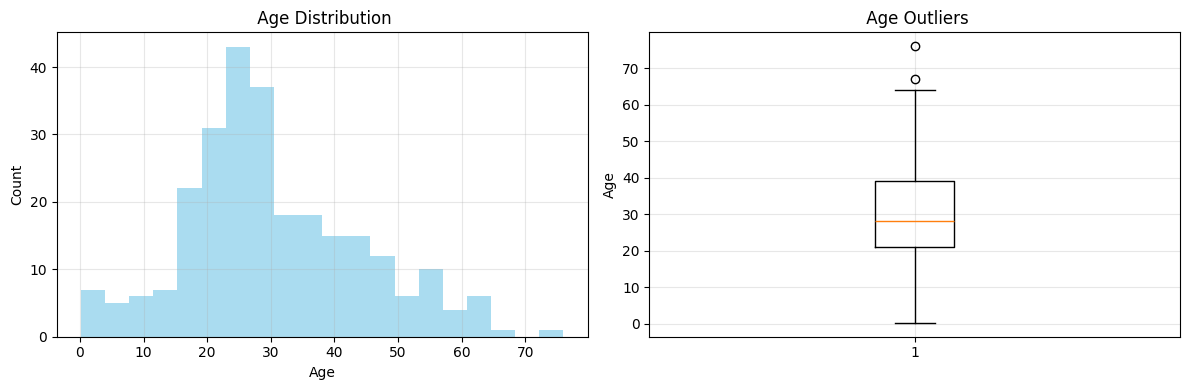


 WHAT YOU CAN SEE:
    Left plot: Shows how data is spread out
    Right plot: Dots outside the box = outliers

 OUTLIERS FOUND:
   • Values: [np.float64(67.0), np.float64(76.0)]

📏 Suggested Bin Counts:
   • Square root rule: 10
   • Sturges rule: 9
   • Recommended: 9-8

 Recommended Strategy:
   • UNIFORM: Data is symmetric with few outliers

 ANALYZING: Fare
----------------------------------------
 Basic Stats:
   • Sample size: 264
   • Range: 0.00 to 512.33
   • Mean: 43.40
   • Median: 20.41
   • Std Dev: 65.11

 Distribution:
   • Skewness: 3.172 (Highly skewed)
   • Outliers: 27 (10.2%)

 SIMPLE VISUAL ANALYSIS:


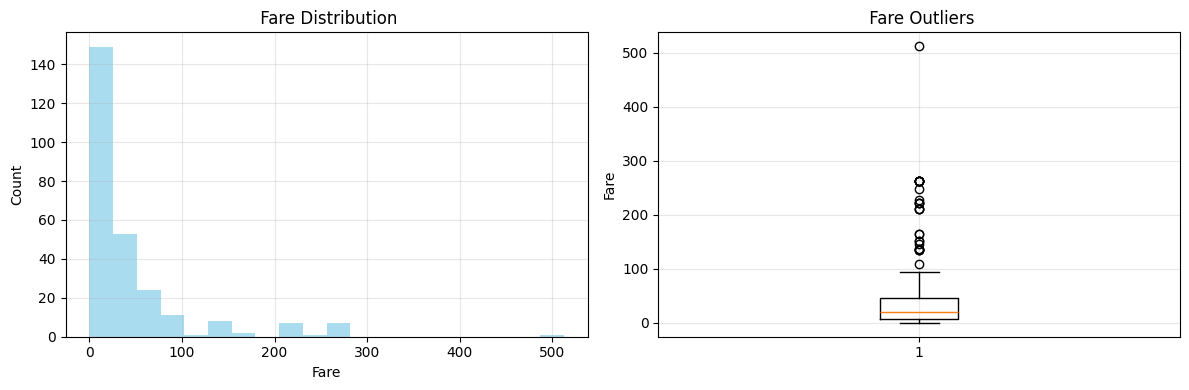


 WHAT YOU CAN SEE:
    Left plot: Shows how data is spread out
    Right plot: Dots outside the box = outliers

 OUTLIERS FOUND:
   • Count: 27 outliers
   • Range: 108.90 to 512.33

📏 Suggested Bin Counts:
   • Square root rule: 10
   • Sturges rule: 9
   • Recommended: 9-8

 Recommended Strategy:
   • QUANTILE: Data is skewed or has many outliers


In [10]:
def analyze_feature_for_binning(data, feature_name, show_plots=True):
    """Analyze a single feature to recommend binning strategy"""
    
    print(f"\n ANALYZING: {feature_name}")
    print("-" * 40)
    
    # Basic statistics
    print(f" Basic Stats:")
    print(f"   • Sample size: {len(data)}")
    print(f"   • Range: {data.min():.2f} to {data.max():.2f}")
    print(f"   • Mean: {data.mean():.2f}")
    print(f"   • Median: {data.median():.2f}")
    print(f"   • Std Dev: {data.std():.2f}")
    
    # Distribution analysis
    skewness = stats.skew(data)
    print(f"\n Distribution:")
    print(f"   • Skewness: {skewness:.3f}", end=" ")
    if abs(skewness) < 0.5:
        print("(Fairly symmetric)")
        distribution = "symmetric"
    elif abs(skewness) < 1:
        print("(Moderately skewed)")
        distribution = "moderate_skew"
    else:
        print("(Highly skewed)")
        distribution = "high_skew"
    
    # Outlier detection
    Q1, Q3 = data.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    outliers = ((data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)).sum()
    outlier_pct = (outliers / len(data)) * 100
    
    print(f"   • Outliers: {outliers} ({outlier_pct:.1f}%)")
    
    #  SIMPLE VISUALIZATION for beginners
    if show_plots:
        print(f"\n SIMPLE VISUAL ANALYSIS:")
        
        # Create simple plots side by side
        plt.figure(figsize=(12, 4))
        
        # 1. Simple Histogram
        plt.subplot(1, 2, 1)
        plt.hist(data, bins=20, color='skyblue', alpha=0.7)
        plt.title(f' {feature_name} Distribution')
        plt.xlabel(feature_name)
        plt.ylabel('Count')
        plt.grid(True, alpha=0.3)
        
        # 2. Simple Box Plot
        plt.subplot(1, 2, 2)
        plt.boxplot(data)
        plt.title(f' {feature_name} Outliers')
        plt.ylabel(feature_name)
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # Simple interpretation
        print(f"\n WHAT YOU CAN SEE:")
        print(f"    Left plot: Shows how data is spread out")
        print(f"    Right plot: Dots outside the box = outliers")
        
        # Show outlier values if any
        if outliers > 0:
            outlier_indices = (data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)
            outlier_values = data[outlier_indices].values
            print(f"\n OUTLIERS FOUND:")
            if len(outlier_values) <= 5:
                print(f"   • Values: {[round(x, 2) for x in sorted(outlier_values)]}")
            else:
                print(f"   • Count: {len(outlier_values)} outliers")
                print(f"   • Range: {outlier_values.min():.2f} to {outlier_values.max():.2f}")
        else:
            print(f"\n No outliers found!")
    else:
        print(f"\n Plots skipped (show_plots=False)")
    
    # Recommended bin counts
    n = len(data)
    sqrt_bins = max(3, min(10, int(np.sqrt(n))))
    sturges_bins = max(3, min(10, int(1 + np.log2(n))))
    
    print(f"\n📏 Suggested Bin Counts:")
    print(f"   • Square root rule: {sqrt_bins}")
    print(f"   • Sturges rule: {sturges_bins}")
    print(f"   • Recommended: {max(3, min(sqrt_bins, sturges_bins))}-{min(8, max(sqrt_bins, sturges_bins))}")
    
    # Strategy recommendation
    print(f"\n Recommended Strategy:")
    if distribution == "symmetric" and outlier_pct < 5:
        recommendation = "UNIFORM"
        reason = "Data is symmetric with few outliers"
    elif distribution == "high_skew" or outlier_pct > 10:
        recommendation = "QUANTILE"
        reason = "Data is skewed or has many outliers"
    else:
        recommendation = "TEST MULTIPLE"
        reason = "Mixed characteristics - test different strategies"
    
    print(f"   • {recommendation}: {reason}")
    
    return {
        'feature': feature_name,
        'recommendation': recommendation,
        'suggested_bins': (max(3, min(sqrt_bins, sturges_bins)), min(8, max(sqrt_bins, sturges_bins))),
        'skewness': skewness,
        'outlier_pct': outlier_pct
    }

# Analyze our features with visualization
print("🔬 DATA ANALYSIS FOR OPTIMAL BINNING")
print("=" * 50)

age_analysis = analyze_feature_for_binning(X_train['Age'], 'Age', show_plots=True)
fare_analysis = analyze_feature_for_binning(X_train['Fare'], 'Fare', show_plots=True)

###  Automated Optimization Function

In [11]:
def find_optimal_binning(X_train, X_test, y_train, y_test, 
                        strategies=['uniform', 'quantile', 'kmeans'],
                        bin_range=(3, 8), verbose=True):
    """
    Automatically find the optimal binning strategy and number of bins
    
    Returns:
    - best_config: Dictionary with optimal configuration
    - all_results: List of all tested configurations
    """
    
    if verbose:
        print(" AUTOMATED BINNING OPTIMIZATION")
        print("=" * 50)
    
    results = []
    best_score = 0
    best_config = None
    
    for strategy in strategies:
        if verbose:
            print(f"\n Testing {strategy.upper()} strategy...")
        
        for n_bins in range(bin_range[0], bin_range[1] + 1):
            try:
                # Create transformer
                transformer = ColumnTransformer([
                    ('age', KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy=strategy), [0]),
                    ('fare', KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy=strategy), [1])
                ])
                
                # Transform data
                X_train_transformed = transformer.fit_transform(X_train)
                X_test_transformed = transformer.transform(X_test)
                
                # Train and evaluate
                clf = DecisionTreeClassifier(random_state=42)
                clf.fit(X_train_transformed, y_train)
                test_acc = clf.score(X_test_transformed, y_test)
                
                # Cross-validation
                X_full = pd.concat([X_train, X_test])
                y_full = pd.concat([y_train, y_test])
                X_full_transformed = transformer.fit_transform(X_full)
                cv_scores = cross_val_score(DecisionTreeClassifier(random_state=42), 
                                          X_full_transformed, y_full, cv=5)
                cv_acc = cv_scores.mean()
                
                # Combined score (average of test and CV)
                combined_score = (test_acc + cv_acc) / 2
                
                result = {
                    'strategy': strategy,
                    'n_bins': n_bins,
                    'test_accuracy': test_acc,
                    'cv_accuracy': cv_acc,
                    'cv_std': cv_scores.std(),
                    'combined_score': combined_score,
                    'transformer': transformer
                }
                
                results.append(result)
                
                if combined_score > best_score:
                    best_score = combined_score
                    best_config = result.copy()
                
                if verbose:
                    print(f"   • {n_bins} bins: Test={test_acc:.3f}, CV={cv_acc:.3f}±{cv_scores.std():.3f}")
                
            except Exception as e:
                if verbose:
                    print(f"   • {n_bins} bins: FAILED ({str(e)[:20]}...)")
                continue
    
    if verbose and best_config:
        print(f"\n BEST CONFIGURATION:")
        print(f"   • Strategy: {best_config['strategy'].upper()}")
        print(f"   • Bins: {best_config['n_bins']}")
        print(f"   • Test Accuracy: {best_config['test_accuracy']:.4f} ({best_config['test_accuracy']*100:.2f}%)")
        print(f"   • CV Accuracy: {best_config['cv_accuracy']:.4f}±{best_config['cv_std']:.4f}")
        print(f"   • Combined Score: {best_config['combined_score']:.4f}")
    
    return best_config, results

# Run optimization
print("\n" + "=" * 60)
optimal_config, all_results = find_optimal_binning(X_train, X_test, y_train, y_test)


 AUTOMATED BINNING OPTIMIZATION

 Testing UNIFORM strategy...
   • 3 bins: Test=0.612, CV=0.625±0.015
   • 4 bins: Test=0.627, CV=0.640±0.025
   • 5 bins: Test=0.597, CV=0.625±0.025
   • 6 bins: Test=0.642, CV=0.628±0.020
   • 7 bins: Test=0.582, CV=0.625±0.029
   • 8 bins: Test=0.582, CV=0.601±0.020

 Testing QUANTILE strategy...
   • 3 bins: Test=0.612, CV=0.589±0.056
   • 4 bins: Test=0.597, CV=0.610±0.049
   • 5 bins: Test=0.642, CV=0.622±0.027
   • 6 bins: Test=0.597, CV=0.586±0.029
   • 7 bins: Test=0.672, CV=0.610±0.036
   • 8 bins: Test=0.552, CV=0.568±0.021

 Testing KMEANS strategy...
   • 3 bins: Test=0.612, CV=0.589±0.056
   • 4 bins: Test=0.597, CV=0.610±0.049
   • 5 bins: Test=0.642, CV=0.622±0.027
   • 6 bins: Test=0.597, CV=0.586±0.029
   • 7 bins: Test=0.672, CV=0.610±0.036
   • 8 bins: Test=0.552, CV=0.568±0.021

 Testing KMEANS strategy...
   • 3 bins: Test=0.612, CV=0.622±0.015
   • 4 bins: Test=0.627, CV=0.604±0.025
   • 5 bins: Test=0.657, CV=0.613±0.026
   • 6 b

###  Results Analysis

In [12]:
# Show top 5 configurations
sorted_results = sorted(all_results, key=lambda x: x['combined_score'], reverse=True)

print("\n TOP 5 CONFIGURATIONS:")
print("=" * 50)
for i, result in enumerate(sorted_results[:5]):
    improvement = (result['test_accuracy'] - baseline_test_acc) * 100
    print(f"{i+1}. {result['strategy'].upper()} + {result['n_bins']} bins:")
    print(f"   Test: {result['test_accuracy']:.3f} | CV: {result['cv_accuracy']:.3f}±{result['cv_std']:.3f}")
    print(f"   Improvement: {improvement:+.2f}% over baseline")

# Compare with baseline
best_improvement = (optimal_config['test_accuracy'] - baseline_test_acc) * 100
print(f"\n FINAL COMPARISON:")
print(f" Baseline (Original): {baseline_test_acc:.4f} ({baseline_test_acc*100:.2f}%)")
print(f"Optimal Binning: {optimal_config['test_accuracy']:.4f} ({optimal_config['test_accuracy']*100:.2f}%)")
print(f" Improvement: {best_improvement:+.2f}%")

if best_improvement > 0:
    print(f"\n SUCCESS! Binning improved performance by {best_improvement:.2f}%")
else:
    print(f"\n NOTE: Original data performed better. Consider:")
    print(f"    • Using different algorithms")
    print(f"    • Feature engineering instead of binning")
    print(f"    • Different binning parameters")


 TOP 5 CONFIGURATIONS:
1. QUANTILE + 7 bins:
   Test: 0.672 | CV: 0.610±0.036
   Improvement: +5.97% over baseline
2. UNIFORM + 6 bins:
   Test: 0.642 | CV: 0.628±0.020
   Improvement: +2.99% over baseline
3. KMEANS + 5 bins:
   Test: 0.657 | CV: 0.613±0.026
   Improvement: +4.48% over baseline
4. UNIFORM + 4 bins:
   Test: 0.627 | CV: 0.640±0.025
   Improvement: +1.49% over baseline
5. QUANTILE + 5 bins:
   Test: 0.642 | CV: 0.622±0.027
   Improvement: +2.99% over baseline

 FINAL COMPARISON:
 Baseline (Original): 0.6119 (61.19%)
Optimal Binning: 0.6716 (67.16%)
 Improvement: +5.97%

 SUCCESS! Binning improved performance by 5.97%


---

## 5.  Key Takeaways & Best Practices <a id="summary"></a>

###  **What We Learned**

1. **Binning can significantly improve model performance** when done right
2. **The "theoretically best" strategy isn't always practically best**
3. **Always test multiple approaches** - data characteristics can be misleading
4. **Validation is crucial** - use cross-validation to avoid overfitting

###  **Decision Framework**

| Step | Action | Tool |
|------|--------|------|
| 1 | **Analyze your data** | `analyze_feature_for_binning()` |
| 2 | **Get quick recommendations** | Decision rules table |
| 3 | **Test systematically** | `find_optimal_binning()` |
| 4 | **Validate results** | Cross-validation |
| 5 | **Apply domain knowledge** | Business understanding |

###  **Common Mistakes to Avoid**

1. **Using too many bins** for small datasets
2. **Not validating** with cross-validation
3. **Ignoring domain knowledge** for business-critical features
4. **Assuming one strategy fits all** features
5. **Not comparing** with baseline performance
6. **Data leakage** - fit transformer on training data only!

###  **Quick Reference**

```python
# For any new dataset:
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer

# 1. Analyze features
analyze_feature_for_binning(your_data['feature'], 'feature')

# 2. Find optimal configuration
best_config, results = find_optimal_binning(X_train, X_test, y_train, y_test)

# 3. Apply optimal binning
transformer = ColumnTransformer([
    ('feature1', KBinsDiscretizer(n_bins=best_bins, strategy=best_strategy), [0]),
    # ... add more features
])

X_train_binned = transformer.fit_transform(X_train)
X_test_binned = transformer.transform(X_test)
```

###  **Remember**

- **Start simple** (3-5 bins) and increase if needed
- **Uniform binning** works well for symmetric data
- **Quantile binning** handles skewed data and outliers
- **K-means binning** captures natural clusters
- **Always validate** your improvements!

---

##  **Final Notes**

This notebook provides a complete framework for discretization/binning. The key is to:
1. **Understand your data** characteristics
2. **Test systematically** rather than guessing
3. **Validate thoroughly** with cross-validation
4. **Apply domain knowledge** when relevant


## 🎯 **SUPER SIMPLE CHEAT SHEET** - No Memory Required!

### 📝 **Step 1: Copy-Paste These Imports (Always Start Here)**
```python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.tree import DecisionTreeClassifier
from sklearn.compose import ColumnTransformer
from scipy import stats
```

### 📝 **Step 2: Load Your Data (Change file path only)**
```python
# Change only the file path and column names
df = pd.read_csv("YOUR_FILE_PATH.csv", usecols=["feature1", "feature2", "target"])
df.dropna(inplace=True)  # Remove missing values
X = df[['feature1', 'feature2']]  # Your features
y = df['target']  # Your target
```

### 📝 **Step 3: Split Data (Copy-paste exactly)**
```python
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
```

### 📝 **Step 4: Copy-Paste Analysis Function**
```python
# Copy the entire analyze_feature_for_binning function from above
# Then use it like this:
analyze_feature_for_binning(X_train['feature1'], 'Feature1')
analyze_feature_for_binning(X_train['feature2'], 'Feature2')
```

### 📝 **Step 5: Copy-Paste Optimization Function**
```python
# Copy the entire find_optimal_binning function from above
# Then use it like this:
best_config, results = find_optimal_binning(X_train, X_test, y_train, y_test)
```

### 📝 **Step 6: Apply Best Binning (Copy-paste, change feature names only)**
```python
# Use the results from step 5
transformer = ColumnTransformer([
    ('feature1', KBinsDiscretizer(n_bins=best_config['n_bins'], 
                                  strategy=best_config['strategy']), [0]),
    ('feature2', KBinsDiscretizer(n_bins=best_config['n_bins'], 
                                  strategy=best_config['strategy']), [1])
])

X_train_binned = transformer.fit_transform(X_train)
X_test_binned = transformer.transform(X_test)
```

### 📝 **Step 7: Train Model (Copy-paste exactly)**
```python
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train_binned, y_train)
accuracy = model.score(X_test_binned, y_test)
print(f"Accuracy: {accuracy:.4f}")
```

---

## 🧠 **DON'T MEMORIZE - JUST FOLLOW THE STEPS!**

**The secret:** You don't need to remember anything! Just:
1. 📋 Keep this cheat sheet open
2. 🔄 Follow steps 1-7 in order
3. ✏️ Only change file paths and column names
4. 📋 Copy-paste everything else exactly

**That's it!** No memory required! 🎉

## 🗺️ **VISUAL FLOWCHART - Never Get Lost Again!**

```
START HERE ⬇️

📦 Step 1: Import Libraries
    ⬇️ (copy-paste imports)
    
📊 Step 2: Load Data  
    ⬇️ (change file path only)
    
✂️ Step 3: Split Data
    ⬇️ (copy-paste exactly)
    
🔍 Step 4: Analyze Features
    ⬇️ (copy function + run on each feature)
    
🤖 Step 5: Find Best Strategy  
    ⬇️ (copy function + run once)
    
⚙️ Step 6: Apply Binning
    ⬇️ (copy-paste, change feature names)
    
🎯 Step 7: Train Model
    ⬇️ (copy-paste exactly)
    
🎉 DONE! ✅
```

### 🎯 **What to Remember vs What to Copy-Paste**

| **REMEMBER** 💭 | **COPY-PASTE** 📋 |
|------------------|-------------------|
| These 7 steps exist | All the actual code |
| Need to change file paths | Import statements |
| Need to change column names | All functions |
| Follow the order 1→7 | Model training code |

### 🚀 **The Magic Formula:**
**20% Thinking** (file paths, column names) + **80% Copy-Paste** = **100% Success!**

---

## 📚 **LET'S BUILD MORE NOTEBOOKS TOGETHER!**

### 🎯 **Suggested Notebook Topics We Can Create:**

| **Notebook Topic** | **What You'll Learn** | **Difficulty** |
|-------------------|---------------------|----------------|
| **Feature Scaling** | StandardScaler, MinMaxScaler, RobustScaler | 🟢 Easy |
| **Handling Missing Data** | fillna, KNNImputer, SimpleImputer | 🟢 Easy |
| **Categorical Encoding** | LabelEncoder, OneHotEncoder, TargetEncoder | 🟡 Medium |
| **Feature Selection** | SelectKBest, RFE, mutual_info | 🟡 Medium |
| **Cross Validation** | train_test_split, KFold, StratifiedKFold | 🟡 Medium |
| **Model Evaluation** | accuracy, precision, recall, F1-score | 🟡 Medium |
| **Pipeline Building** | sklearn Pipeline, fit_transform | 🔴 Advanced |
| **Hyperparameter Tuning** | GridSearchCV, RandomizedSearchCV | 🔴 Advanced |

### 🚀 **How We'll Work Together:**

#### **Option 1: Pick a Topic** 
```
You: "I want to learn Feature Scaling"
Me: Creates complete notebook with:
   ✅ Theory explanation
   ✅ Step-by-step code
   ✅ Beginner-friendly examples
   ✅ Cheat sheet for future use
```

#### **Option 2: Problem-Based Learning**
```
You: "I have a dataset with missing values"
Me: Creates notebook specifically for your data:
   ✅ Load your actual data
   ✅ Analyze missing patterns
   ✅ Apply best techniques
   ✅ Give you working solution
```

#### **Option 3: Build on Existing**
```
You: "Can we add feature scaling to this binning notebook?"
Me: Extends current notebook with new sections
```

### 🎯 **What Makes Our Notebooks Special:**

- ✅ **No memorization required** - always include cheat sheets
- ✅ **Beginner-friendly** - simple explanations and visuals
- ✅ **Copy-paste ready** - working code you can reuse
- ✅ **Real examples** - using actual datasets
- ✅ **Step-by-step flow** - never get lost
- ✅ **Professional quality** - ready for work/interviews

---

## 🤝 **Ready to Start?**

**Just tell me:**
1. 📋 **What topic** interests you most?
2. 📊 **Do you have a dataset** to work with?
3. 🎯 **Any specific problem** you're facing?

**Then we'll build an amazing notebook together!** 🚀✨